In [2]:
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix


Mounted at /content/drive


Evaluation data and model loaded.
Accuracy : 0.8533
F1 Score : 0.8683
ROC AUC  : 0.9223


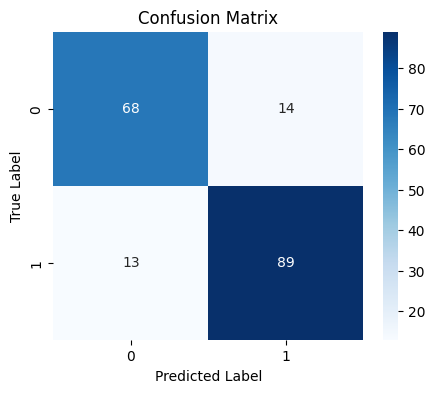

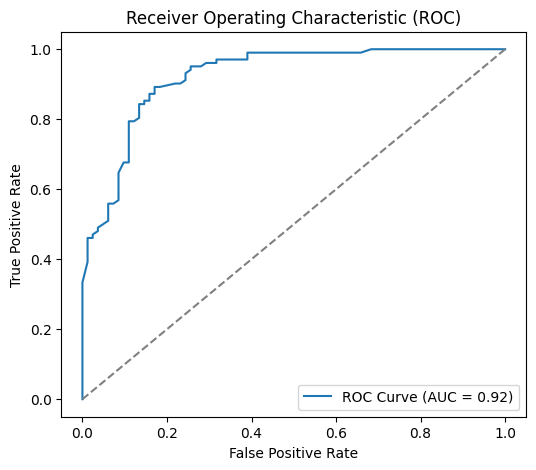

              precision    recall  f1-score   support

  No Disease       0.84      0.83      0.83        82
     Disease       0.86      0.87      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [4]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
# Paths
PROJECT_ROOT = "/content/drive/MyDrive/heart_disease_project"
PROCESSED_DATA_PATH = PROJECT_ROOT + "/data/processed"
MODELS_PATH = PROJECT_ROOT + "/models"

# Load test data
X_test = np.load(PROCESSED_DATA_PATH + "/X_test.npy")
y_test = np.load(PROCESSED_DATA_PATH + "/y_test.npy")

# Load trained model
model = joblib.load(MODELS_PATH + "/best_model.pkl")

print("Evaluation data and model loaded.")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.show()
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))


Evaluation Summary


The Random Forest model achieved strong predictive performance on unseen test data, with a high ROC-AUC score, indicating good separation between patients with and without heart disease. The confusion matrix shows that the model correctly identifies most disease cases, which is critical in medical diagnosis where false negatives must be minimized.

In [5]:
assert len(y_test) == len(y_pred)
print("Evaluation completed successfully.")

Evaluation completed successfully.
